# Bivariate Analysis

This notebook explores pairwise relationships and failure-rate differences. Findings are descriptive and should be validated with time-aware modelling and operational context.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', context='notebook')
ROOT = Path.cwd().parent
if not (ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv').exists():
    ROOT = Path.cwd() / 'PROJECT 1'
df = pd.read_csv(ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv')
df['timestamp_parsed'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')
display(Markdown(f'Loaded **{df.shape[0]:,} observations**. Timestamp parsing failures: **{df.timestamp_parsed.isna().sum():,}**.'))

Loaded **131,760 observations**. Timestamp parsing failures: **77,760**.

## Failure rate by turbine

,observations,failures,failure_rate_pct
turbine_id,,,
T001,8784,558,6.35%
T007,8784,492,5.60%
T008,8784,478,5.44%
T004,8784,355,4.04%
T013,8784,337,3.84%
T006,8784,281,3.20%
T012,8784,244,2.78%
T005,8784,240,2.73%
T015,8784,230,2.62%


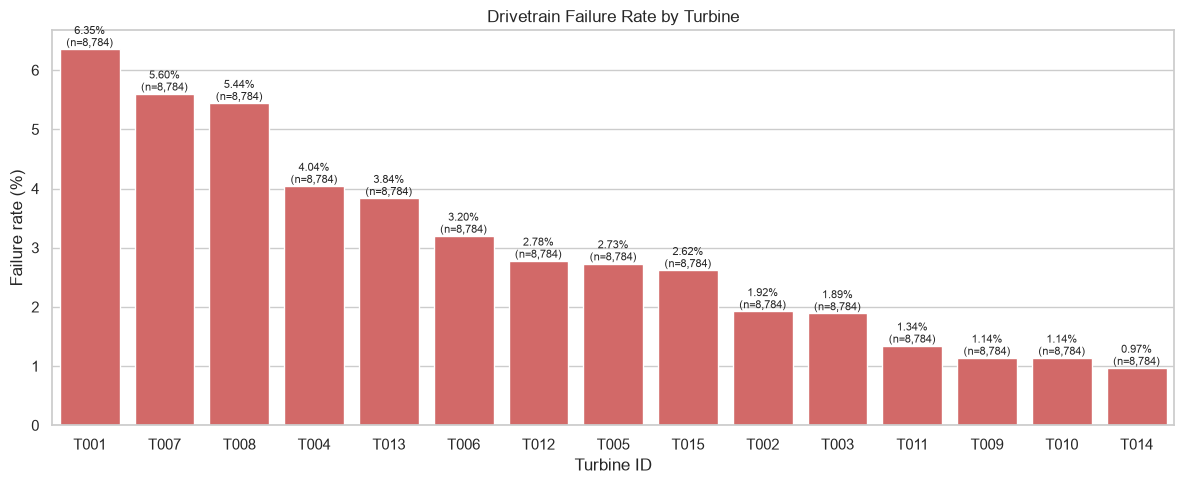

**Interpretation:** `T001` has the highest failure rate (**6.35%**), while `T014` has the lowest (**0.97%**). The range is **5.38 percentage points**. This indicates that target prevalence is not fully consistent across turbines; turbine identity, age, operating conditions, and chronology should be considered during validation.

In [2]:
## Failure rate by turbine
display(Markdown('## Failure rate by turbine'))
turbine_summary = df.groupby('turbine_id')['failure'].agg(observations='size', failures='sum', failure_rate='mean').sort_values('failure_rate', ascending=False)
turbine_summary['failure_rate_pct'] = turbine_summary['failure_rate'] * 100
display(turbine_summary[['observations', 'failures', 'failure_rate_pct']].style.format({'failure_rate_pct': '{:.2f}%'}))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=turbine_summary.reset_index(), x='turbine_id', y='failure_rate_pct', color='#E45756', ax=ax)
for index, row in turbine_summary.reset_index().iterrows():
    ax.text(index, row.failure_rate_pct, f"{row.failure_rate_pct:.2f}%\n(n={row.observations:,})", ha='center', va='bottom', fontsize=8)
ax.set(title='Drivetrain Failure Rate by Turbine', xlabel='Turbine ID', ylabel='Failure rate (%)')
plt.tight_layout(); plt.show(); plt.close(fig)
highest, lowest = turbine_summary.index[0], turbine_summary.index[-1]
rate_range = turbine_summary.failure_rate_pct.max() - turbine_summary.failure_rate_pct.min()
display(Markdown(f'**Interpretation:** `{highest}` has the highest failure rate (**{turbine_summary.loc[highest].failure_rate_pct:.2f}%**), while `{lowest}` has the lowest (**{turbine_summary.loc[lowest].failure_rate_pct:.2f}%**). The range is **{rate_range:.2f} percentage points**. This indicates that target prevalence is not fully consistent across turbines; turbine identity, age, operating conditions, and chronology should be considered during validation.'))

## Wind speed and power output

,observations,average_power_kW
wind_speed_bin,,
"[0, 3)",14875,0.00
"[3, 6)",36166,26.32
"[6, 9)",37284,294.05
"[9, 12)",24633,1246.04
"[12, 15)",11882,2174.01
"[15, 18)",4704,2201.70
"[18, 21)",1560,2222.36
"[21, 24)",495,2249.45
"[24, 27)",120,886.06


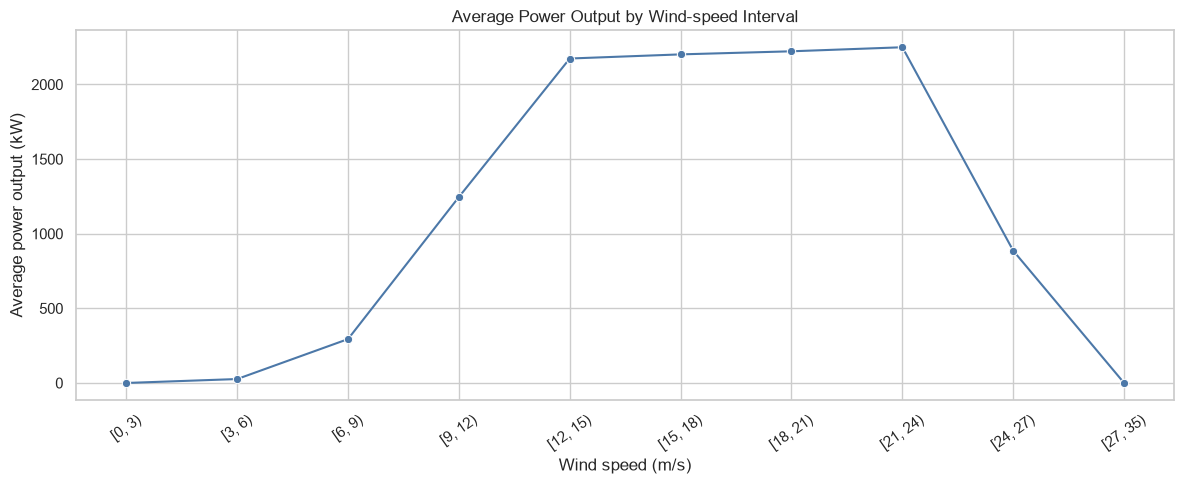

**Interpretation:** Average power rises as wind speed increases, showing the expected non-linear turbine power curve. The highest average output occurs in **[21, 24)** at **2,249 kW**. Inspect the upper intervals for a plateau or decline, which can reflect rated-power control, cut-out logic, or fewer observations rather than a simple linear relationship.

In [3]:
## Wind speed and power output
display(Markdown('## Wind speed and power output'))
bin_edges = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 35]
df['wind_speed_bin'] = pd.cut(df['wind_speed_mps'], bins=bin_edges, include_lowest=True, right=False)
wind_power = df.groupby('wind_speed_bin', observed=False)['power_output_kW'].agg(observations='size', average_power_kW='mean').dropna()
display(wind_power.round(2))
fig, ax = plt.subplots(figsize=(12, 5))
wind_power_plot = wind_power.reset_index().assign(wind_speed_interval=lambda data: data['wind_speed_bin'].astype(str))
sns.lineplot(data=wind_power_plot, x='wind_speed_interval', y='average_power_kW', marker='o', color='#4C78A8', ax=ax)
ax.tick_params(axis='x', rotation=35); ax.set(title='Average Power Output by Wind-speed Interval', xlabel='Wind speed (m/s)', ylabel='Average power output (kW)')
plt.tight_layout(); plt.show(); plt.close(fig)
max_bin = wind_power.average_power_kW.idxmax()
display(Markdown(f'**Interpretation:** Average power rises as wind speed increases, showing the expected non-linear turbine power curve. The highest average output occurs in **{max_bin}** at **{wind_power.average_power_kW.max():,.0f} kW**. Inspect the upper intervals for a plateau or decline, which can reflect rated-power control, cut-out logic, or fewer observations rather than a simple linear relationship.'))

## Rotor speed and generator speed

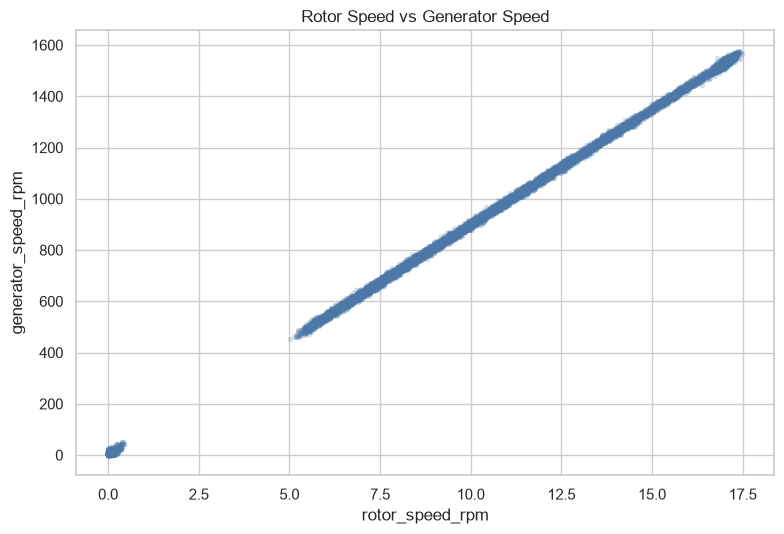

**Interpretation:** The relationship is **strong and positive** (Pearson r = **1.000**). The plot uses a reproducible 15,000-record sample for readability. **1,780** records (1.35%) sit outside the pairwise 1st–99th percentile bounds; inspect these candidates with operating state and turbine context before treating them as anomalies.

## Wind speed and rotor speed

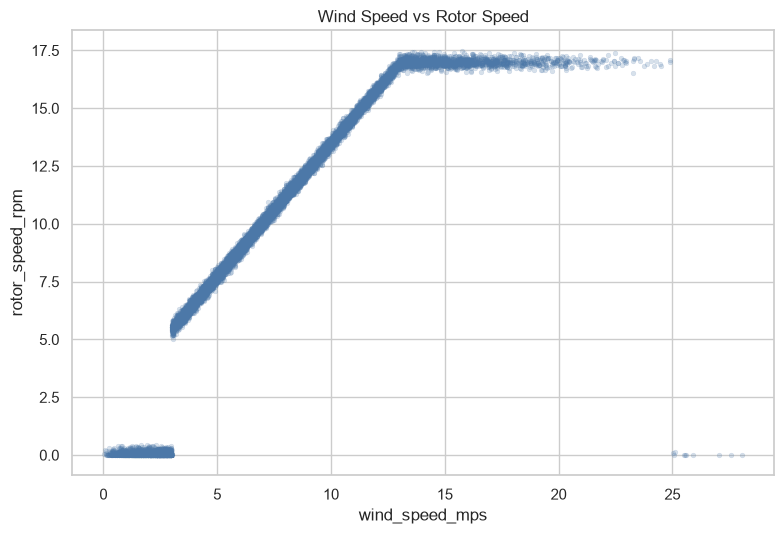

**Interpretation:** The relationship is **strong and positive** (Pearson r = **0.911**). The plot uses a reproducible 15,000-record sample for readability. **3,837** records (2.91%) sit outside the pairwise 1st–99th percentile bounds; inspect these candidates with operating state and turbine context before treating them as anomalies.

In [4]:
def scatter_relationship(x, y, title):
    pair = df[[x, y]].dropna()
    plot_data = pair.sample(min(15000, len(pair)), random_state=42)
    correlation = pair[x].corr(pair[y])
    x_low, x_high = pair[x].quantile([0.01, 0.99])
    y_low, y_high = pair[y].quantile([0.01, 0.99])
    outside = ((pair[x] < x_low) | (pair[x] > x_high) | (pair[y] < y_low) | (pair[y] > y_high)).sum()
    fig, ax = plt.subplots(figsize=(8, 5.5))
    sns.scatterplot(data=plot_data, x=x, y=y, alpha=.22, s=12, color='#4C78A8', edgecolor=None, ax=ax)
    ax.set(title=title)
    plt.tight_layout(); plt.show(); plt.close(fig)
    strength = 'strong' if abs(correlation) >= .7 else ('moderate' if abs(correlation) >= .4 else 'weak')
    direction = 'positive' if correlation >= 0 else 'negative'
    display(Markdown(f'**Interpretation:** The relationship is **{strength} and {direction}** (Pearson r = **{correlation:.3f}**). The plot uses a reproducible 15,000-record sample for readability. **{outside:,}** records ({outside / len(pair):.2%}) sit outside the pairwise 1st–99th percentile bounds; inspect these candidates with operating state and turbine context before treating them as anomalies.'))

display(Markdown('## Rotor speed and generator speed'))
scatter_relationship('rotor_speed_rpm', 'generator_speed_rpm', 'Rotor Speed vs Generator Speed')
display(Markdown('## Wind speed and rotor speed'))
scatter_relationship('wind_speed_mps', 'rotor_speed_rpm', 'Wind Speed vs Rotor Speed')

## Drivetrain RMS Vibration (mm/s) by failure class

,observations,median,mean,standard_deviation,p25,p75
condition,,,,,,
Normal (0),127807,1.681,1.786,0.413,1.502,1.953
Fault (1),3953,3.635,3.407,0.884,3.199,3.982


/var/folders/3h/hpst4wl10_7drtqb6px6gyqw0000gn/T/ipykernel_75315/1086077846.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='condition', y=column, order=['Normal (0)', 'Fault (1)'], palette=['#4C78A8', '#E45756'], ax=ax)


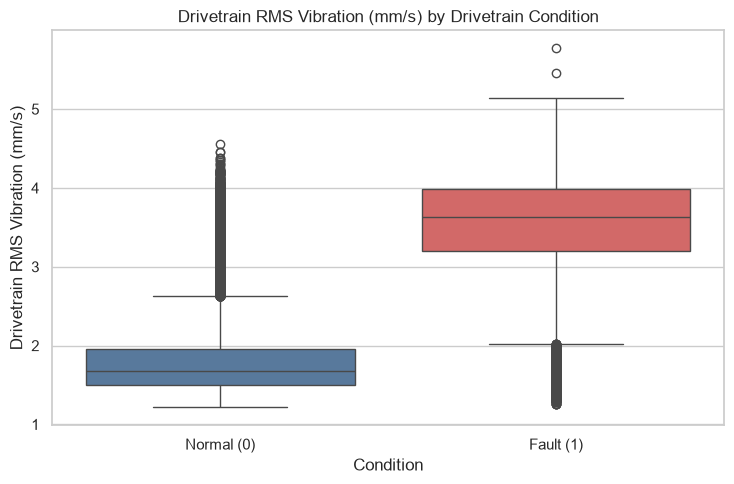

**Interpretation:** The fault median is **+1.95** relative to normal. The IQR overlap is **0**, so the classes show **a potentially useful univariate signal**. Box-plot points beyond whiskers are potential outliers; assess them by turbine and operating condition rather than removing them automatically.

## Oil Particle Count by failure class

,observations,median,mean,standard_deviation,p25,p75
condition,,,,,,
Normal (0),127807,64.450,71.118,25.315,58.479,74.035
Fault (1),3953,165.209,158.083,69.222,136.034,181.295


/var/folders/3h/hpst4wl10_7drtqb6px6gyqw0000gn/T/ipykernel_75315/1086077846.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='condition', y=column, order=['Normal (0)', 'Fault (1)'], palette=['#4C78A8', '#E45756'], ax=ax)


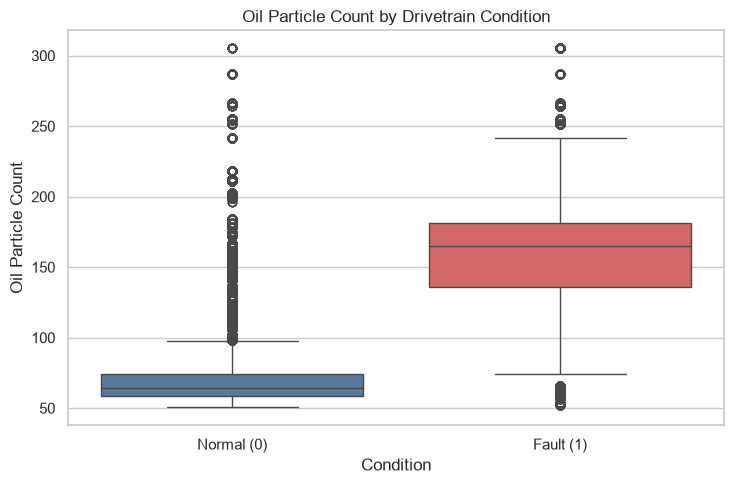

**Interpretation:** The fault median is **+101** relative to normal. The IQR overlap is **0**, so the classes show **a potentially useful univariate signal**. Box-plot points beyond whiskers are potential outliers; assess them by turbine and operating condition rather than removing them automatically.

## Gearbox Bearing Temperature (°C) by failure class

,observations,median,mean,standard_deviation,p25,p75
condition,,,,,,
Normal (0),127807,57.935,62.480,13.214,52.676,70.267
Fault (1),3953,69.072,70.249,14.242,58.750,79.011


/var/folders/3h/hpst4wl10_7drtqb6px6gyqw0000gn/T/ipykernel_75315/1086077846.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='condition', y=column, order=['Normal (0)', 'Fault (1)'], palette=['#4C78A8', '#E45756'], ax=ax)


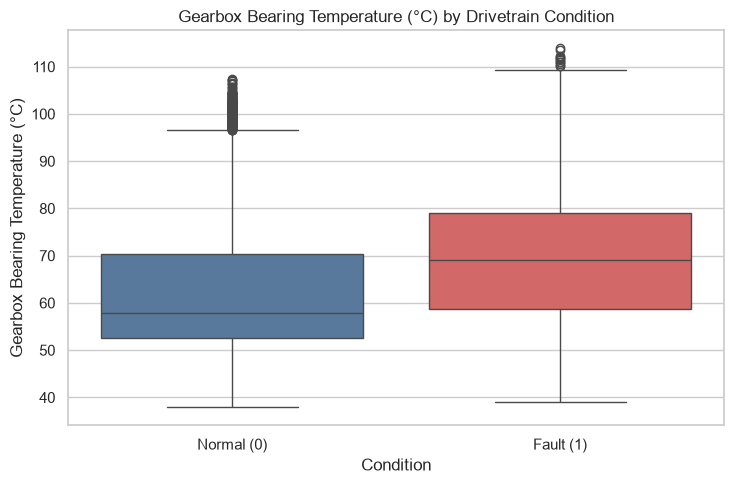

**Interpretation:** The fault median is **+11.1** relative to normal. The IQR overlap is **11.5**, so the classes show **a potentially useful univariate signal**. Box-plot points beyond whiskers are potential outliers; assess them by turbine and operating condition rather than removing them automatically.

## Power Output (kW) by failure class

,observations,median,mean,standard_deviation,p25,p75
condition,,,,,,
Normal (0),127807,200.885,636.599,871.489,17.578,1023.032
Fault (1),3953,136.675,536.910,800.101,11.921,762.341


/var/folders/3h/hpst4wl10_7drtqb6px6gyqw0000gn/T/ipykernel_75315/1086077846.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='condition', y=column, order=['Normal (0)', 'Fault (1)'], palette=['#4C78A8', '#E45756'], ax=ax)


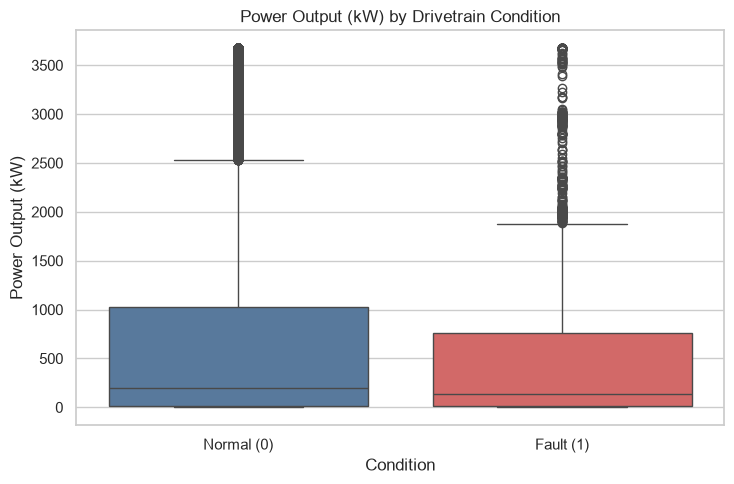

**Interpretation:** The fault median is **-64.2** relative to normal. The IQR overlap is **745**, so the classes show **limited standalone separation**. Box-plot points beyond whiskers are potential outliers; assess them by turbine and operating condition rather than removing them automatically.

## Prior Fault Count by failure class

,observations,median,mean,standard_deviation,p25,p75
condition,,,,,,
Normal (0),127807,0.0,14.191,33.931,0.0,4.0
Fault (1),3953,1.0,33.615,50.369,0.0,48.0


/var/folders/3h/hpst4wl10_7drtqb6px6gyqw0000gn/T/ipykernel_75315/1086077846.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='condition', y=column, order=['Normal (0)', 'Fault (1)'], palette=['#4C78A8', '#E45756'], ax=ax)


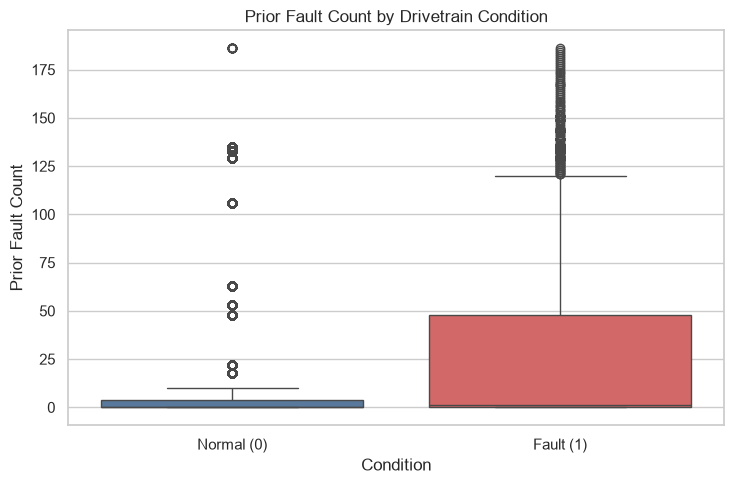

**Interpretation:** The fault median is **+1** relative to normal. The IQR overlap is **4**, so the classes show **limited standalone separation**. Box-plot points beyond whiskers are potential outliers; assess them by turbine and operating condition rather than removing them automatically.

In [5]:
def failure_boxplot(column, label):
    plot_data = df[['failure', column]].dropna().copy()
    plot_data['condition'] = plot_data['failure'].map({0: 'Normal (0)', 1: 'Fault (1)'})
    comparison = plot_data.groupby('condition', observed=False)[column].agg(
        observations='size', median='median', mean='mean', standard_deviation='std',
        p25=lambda x: x.quantile(.25), p75=lambda x: x.quantile(.75)
    ).reindex(['Normal (0)', 'Fault (1)'])
    display(Markdown(f'## {label} by failure class'))
    display(comparison.round(3))
    fig, ax = plt.subplots(figsize=(7.5, 5))
    sns.boxplot(data=plot_data, x='condition', y=column, order=['Normal (0)', 'Fault (1)'], palette=['#4C78A8', '#E45756'], ax=ax)
    ax.set(title=f'{label} by Drivetrain Condition', xlabel='Condition', ylabel=label)
    plt.tight_layout(); plt.show(); plt.close(fig)
    median_difference = comparison.loc['Fault (1)', 'median'] - comparison.loc['Normal (0)', 'median']
    overlap = max(0, min(comparison.loc['Normal (0)', 'p75'], comparison.loc['Fault (1)', 'p75']) - max(comparison.loc['Normal (0)', 'p25'], comparison.loc['Fault (1)', 'p25']))
    min_iqr = min(comparison.loc['Normal (0)', 'p75'] - comparison.loc['Normal (0)', 'p25'], comparison.loc['Fault (1)', 'p75'] - comparison.loc['Fault (1)', 'p25'])
    signal = 'a potentially useful univariate signal' if abs(median_difference) > .25 * max(min_iqr, 1e-9) else 'limited standalone separation'
    display(Markdown(f'**Interpretation:** The fault median is **{median_difference:+.3g}** relative to normal. The IQR overlap is **{overlap:.3g}**, so the classes show **{signal}**. Box-plot points beyond whiskers are potential outliers; assess them by turbine and operating condition rather than removing them automatically.'))

failure_boxplot('drivetrain_vibration_rms_mmps', 'Drivetrain RMS Vibration (mm/s)')
failure_boxplot('oil_particle_count', 'Oil Particle Count')
failure_boxplot('gearbox_bearing_temp_C', 'Gearbox Bearing Temperature (°C)')
failure_boxplot('power_output_kW', 'Power Output (kW)')
failure_boxplot('prior_fault_count', 'Prior Fault Count')

## Drivetrain failure rate by hour of day

,observations,failures,failure_rate_pct
hour,,,
0.000000,2250,22,0.98%
1.000000,2250,26,1.16%
2.000000,2250,30,1.33%
3.000000,2250,30,1.33%
4.000000,2250,30,1.33%
5.000000,2250,27,1.20%
6.000000,2250,30,1.33%
7.000000,2250,28,1.24%
8.000000,2250,33,1.47%


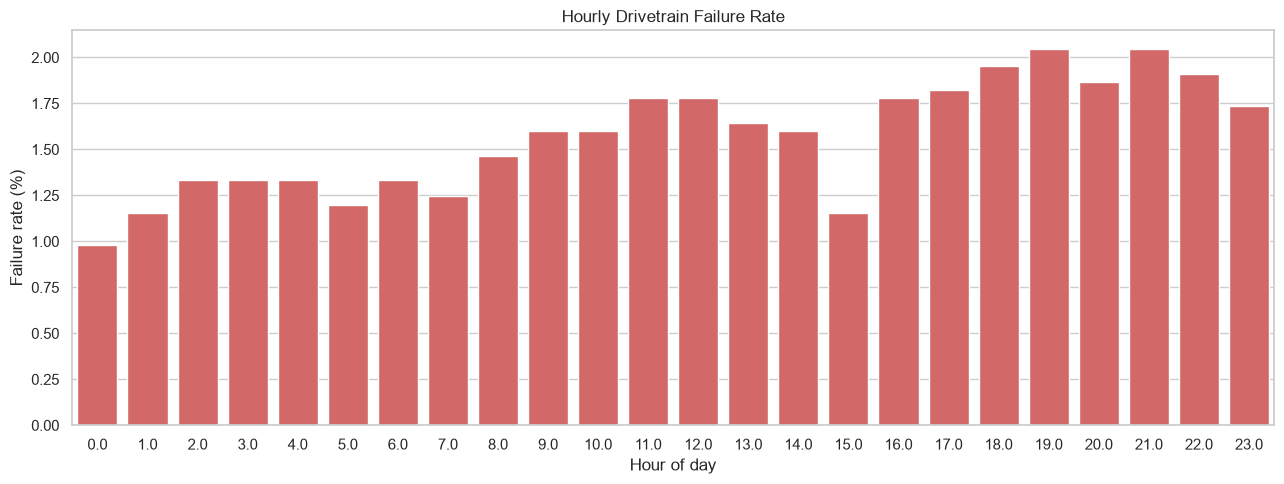

**Interpretation:** The highest hourly rate is at **19:00** (2.04%), and the lowest is at **00:00** (0.98%). Differences should be interpreted cautiously because failure events can cluster in time and may be driven by wind, load, or maintenance patterns rather than clock time itself.

In [6]:
## Hourly failure rate
display(Markdown('## Drivetrain failure rate by hour of day'))
df['hour'] = df['timestamp_parsed'].dt.hour
hourly = df.groupby('hour')['failure'].agg(observations='size', failures='sum', failure_rate='mean')
hourly['failure_rate_pct'] = hourly.failure_rate * 100
display(hourly[['observations', 'failures', 'failure_rate_pct']].style.format({'failure_rate_pct': '{:.2f}%'}))
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=hourly.reset_index(), x='hour', y='failure_rate_pct', color='#E45756', ax=ax)
ax.set(title='Hourly Drivetrain Failure Rate', xlabel='Hour of day', ylabel='Failure rate (%)')
plt.tight_layout(); plt.show(); plt.close(fig)
high_hour, low_hour = hourly.failure_rate_pct.idxmax(), hourly.failure_rate_pct.idxmin()
display(Markdown(f'**Interpretation:** The highest hourly rate is at **{high_hour:02.0f}:00** ({hourly.loc[high_hour].failure_rate_pct:.2f}%), and the lowest is at **{low_hour:02.0f}:00** ({hourly.loc[low_hour].failure_rate_pct:.2f}%). Differences should be interpreted cautiously because failure events can cluster in time and may be driven by wind, load, or maintenance patterns rather than clock time itself.'))

## Drivetrain failure rate by day of week

,observations,failures,failure_rate_pct
day_of_week,,,
Monday,10800,107,0.99%
Tuesday,8640,134,1.55%
Wednesday,6480,286,4.41%
Thursday,6480,0,0.00%
Friday,8640,281,3.25%
Saturday,6480,0,0.00%
Sunday,6480,40,0.62%


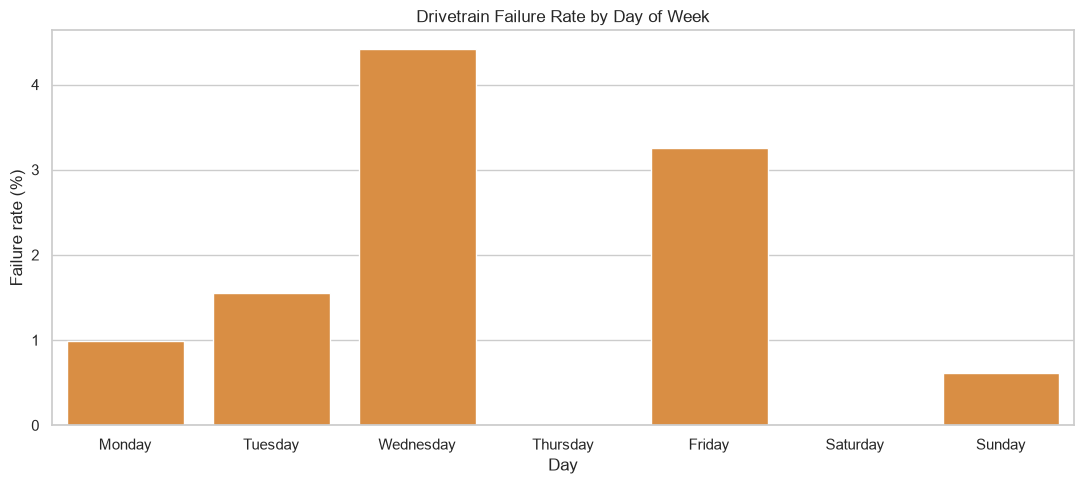

**Interpretation:** **Wednesday** has the highest rate (4.41%), while **Thursday** has the lowest (0.00%). Compare the size of this spread with seasonal, turbine-level, and maintenance effects before concluding that there is a recurring weekly pattern.

In [7]:
## Day-of-week failure rate
display(Markdown('## Drivetrain failure rate by day of week'))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['timestamp_parsed'].dt.day_name(), categories=day_order, ordered=True)
daily = df.groupby('day_of_week', observed=False)['failure'].agg(observations='size', failures='sum', failure_rate='mean')
daily['failure_rate_pct'] = daily.failure_rate * 100
display(daily[['observations', 'failures', 'failure_rate_pct']].style.format({'failure_rate_pct': '{:.2f}%'}))
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=daily.reset_index(), x='day_of_week', y='failure_rate_pct', color='#F28E2B', ax=ax)
ax.set(title='Drivetrain Failure Rate by Day of Week', xlabel='Day', ylabel='Failure rate (%)')
plt.tight_layout(); plt.show(); plt.close(fig)
high_day, low_day = daily.failure_rate_pct.idxmax(), daily.failure_rate_pct.idxmin()
display(Markdown(f'**Interpretation:** **{high_day}** has the highest rate ({daily.loc[high_day].failure_rate_pct:.2f}%), while **{low_day}** has the lowest ({daily.loc[low_day].failure_rate_pct:.2f}%). Compare the size of this spread with seasonal, turbine-level, and maintenance effects before concluding that there is a recurring weekly pattern.'))